In [44]:
import xarray as xr
import matplotlib.pyplot as plt
import oggm.cfg as cfg
from oggm import utils, workflow, tasks, DEFAULT_BASE_URL
from oggm.shop import gcm_climate
import pandas as pd

In [50]:
# Initialize OGGM and set up the default run parameters
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir('OGGM_gcm_run', reset=True)

# Define the glacier IDs
rgi_ids = ['RGI60-06.00291']

# Get the pre-processed glacier directories
gdirs = workflow.init_glacier_directories(rgi_ids, from_prepro_level=5, prepro_base_url=DEFAULT_BASE_URL)


2025-03-10 21:25:08: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-03-10 21:25:08: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-03-10 21:25:08: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2025-03-10 21:25:08: oggm.workflow: init_glacier_directories from prepro level 5 on 1 glaciers.
2025-03-10 21:25:08: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [51]:
# Define the 5 GCMs and SSP scenarios
gcms = [
    'gfdl-esm4_r1i1p1f1',
    'mpi-esm1-2-hr_r1i1p1f1',
    'mri-esm2-0_r1i1p1f1',
    'ipsl-cm6a-lr_r1i1p1f1',
    'ukesm1-0-ll_r1i1p1f2'
]
scenarios = ['ssp126', 'ssp370', 'ssp585']



In [52]:
# Download and process GCM data
for gcm in gcms:
    for ssp in scenarios:
        workflow.execute_entity_task(
            gcm_climate.process_monthly_isimip_data,
            gdirs,
            ssp=ssp,
            member=gcm,
            output_filesuffix=f'_ISIMIP3b_{gcm}_{ssp}'
        )

# Perform a spinup based on historical data
ds_spinup = utils.compile_run_output(gdirs, input_filesuffix='_spinup_historical')

# Run projections for each GCM and SSP scenario
for gcm in gcms:
    for ssp in scenarios:
        rid = f'_ISIMIP3b_{gcm}_{ssp}'
        workflow.execute_entity_task(
            tasks.run_from_climate_data, gdirs,
            climate_filename='gcm_data',
            climate_input_filesuffix=rid,
            init_model_filesuffix='_spinup_historical',
            output_filesuffix=rid
        )




2025-03-10 21:25:09: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:25:10: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:25:12: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:25:13: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:25:14: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:25:15: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:25:17: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:25:18: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:25:19: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-10 21:25:20: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1

In [48]:
# Compile results for each GCM and SSP scenario
results = []
for gcm in gcms:
    for ssp in scenarios:
        rid = f'_ISIMIP3b_{gcm}_{ssp}'
        ds_proj = utils.compile_run_output(gdirs, input_filesuffix=rid)
        ds_proj = ds_proj.assign_coords(GCM=gcm, SCENARIO=ssp)
        results.append(ds_proj)

# Combine all results into a single dataset (ds)
ds_total = xr.concat(results, dim='run')

# Calculate statistics for volume and area
ds_total_volume = ds_total.volume.groupby('SCENARIO').sum(dim='rgi_id')
ds_total_area = ds_total.area.groupby('SCENARIO').sum(dim='rgi_id')

# Calculate reference values for 2020
volume_2020 = ds_total_volume.sel(time='2020', method='nearest')
area_2020 = ds_total_area.sel(time='2020', method='nearest')

# Calculate relative changes 
ds_total_volume_rel = -((volume_2020 - ds_total_volume) / volume_2020 * 100)
ds_total_area_rel = -((area_2020 - ds_total_area) / area_2020 * 100)

# Calculate smean and standard devation
for ds in [ds_total_volume_rel, ds_total_area_rel]:
    globals()[f"{ds.name}_mean"] = ds.groupby('SCENARIO').mean(dim='run')
    globals()[f"{ds.name}_std"] = ds.groupby('SCENARIO').std(dim='run')  # Standard deviation


2025-03-10 21:23:43: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-10 21:23:43: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-10 21:23:43: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-10 21:23:43: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-10 21:23:43: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-10 21:23:43: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-10 21:23:43: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-10 21:23:43: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-10 21:23:43: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-10 21:23:43: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-10 21:23:43: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-10 21:23:43: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-10 21:23:44: oggm.utils: Applyin

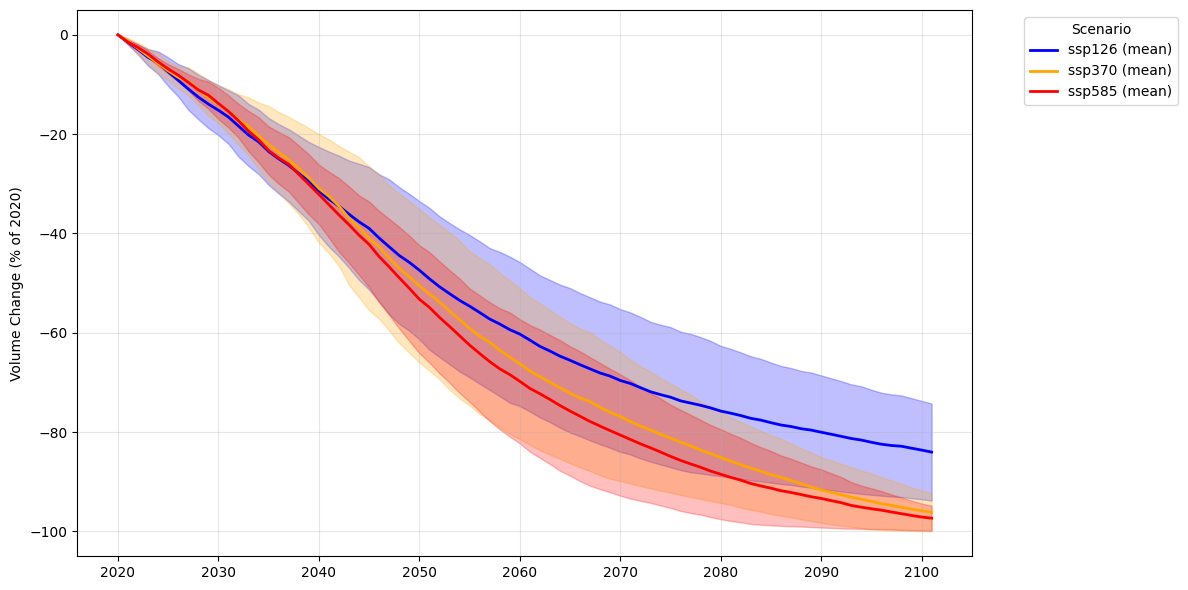

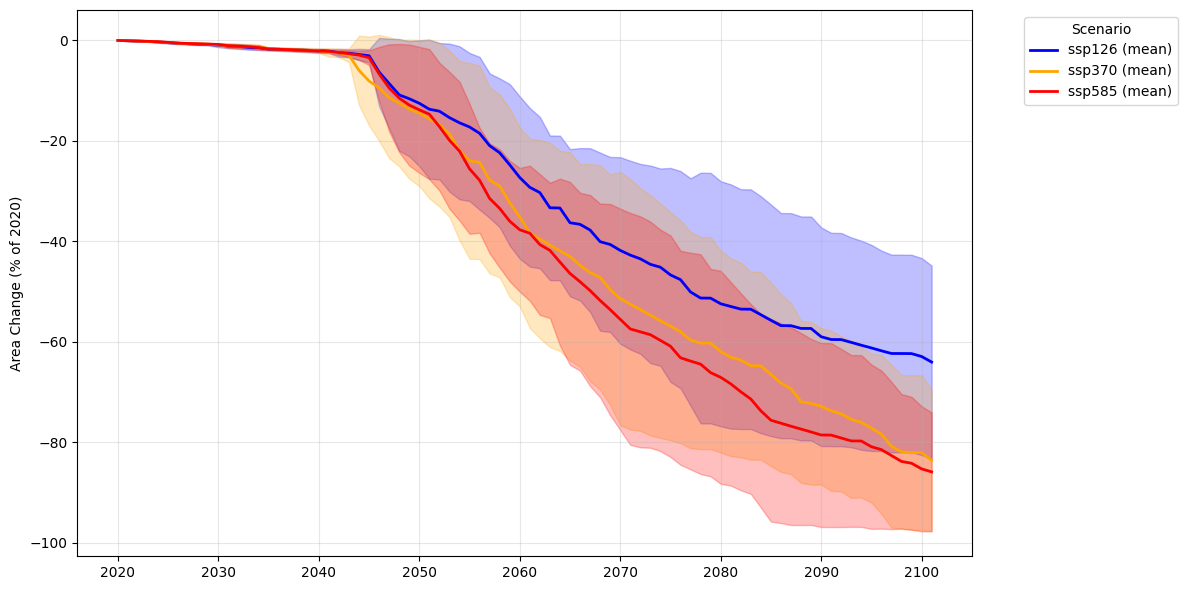

In [49]:
# Colour dictionary for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Plot volume changes with improved colors
fig1, ax1 = plt.subplots(figsize=(12, 6))
for scenario in color_dict.keys():
    # Plot mean volume change
    ax1.plot(
        volume_mean.time,
        volume_mean.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        label=f'{scenario} (mean)',
        lw=2
    )
    # Add shaded region 
    ax1.fill_between(
        volume_mean.time,
        volume_mean.sel(SCENARIO=scenario) - volume_std.sel(SCENARIO=scenario),
        volume_mean.sel(SCENARIO=scenario) + volume_std.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        alpha=0.25  # Slightly lower alpha
    )

ax1.set_ylabel('Volume Change (% of 2020)')
ax1.grid(True, alpha=0.3)  # Lighter grid
ax1.legend(title='Scenario', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Volume_Changes_2100.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot area changes 
fig2, ax2 = plt.subplots(figsize=(12, 6))
for scenario in color_dict.keys():
    # Plot mean area change
    ax2.plot(
        area_mean.time,
        area_mean.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        label=f'{scenario} (mean)',
        lw=2
    )
    # Add shaded region
    ax2.fill_between(
        area_mean.time,
        area_mean.sel(SCENARIO=scenario) - area_std.sel(SCENARIO=scenario),
        area_mean.sel(SCENARIO=scenario) + area_std.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        alpha=0.25  # Consistent alpha
    )

ax2.set_ylabel('Area Change (% of 2020)')
ax2.grid(True, alpha=0.3)
ax2.legend(title='Scenario', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Area_Changes_2100.png', dpi=300, bbox_inches='tight')
plt.show()


In [43]:
# Extract values for 2100 for each GCM and SSP combination
gcm_ssp_results = []
for gcm in gcms:
    for ssp in scenarios:
        rid = f'_ISIMIP3b_{gcm}_{ssp}'
        ds_proj = utils.compile_run_output(gdirs, input_filesuffix=rid)
        
        # Calculate volume at 2100 and 2020
        volume_2100 = ds_proj.volume.sel(time='2100', method='nearest').sum(dim='rgi_id')
        volume_2020 = ds_proj.volume.sel(time='2020', method='nearest').sum(dim='rgi_id')
        
        # Calculate percentage of volume loss relative to 2020 (negative value)
        volume_loss_percentage = -((volume_2020 - volume_2100) / volume_2020 * 100)
        
        # Calculate area at 2100 and 2020
        area_2100 = ds_proj.area.sel(time='2100', method='nearest').sum(dim='rgi_id')
        area_2020 = ds_proj.area.sel(time='2020', method='nearest').sum(dim='rgi_id')*1e-6
        
        # Calculate percentage of area loss relative to 2020 (negative value)
        area_loss_percentage = -((area_2020 - area_2100) / area_2020 * 100)

        # Append results
        gcm_ssp_results.append({
            'GCM': gcm,
            'Scenario': ssp,
            'Volume 2100 (m³)': round(float(volume_2100.values), 2),  # Volume at 2100
            'Volume Loss (%)': round(float(volume_loss_percentage.values), 1),  # % of volume loss (negative)
            'Area 2100 (km²)': round(float(area_2100.values), 2),  # Area at 2100
            'Area Loss (%)': round(float(area_loss_percentage.values), 1)  # % of area loss (negative)
        })

# Create a DataFrame from the results
df_gcm_ssp = pd.DataFrame(gcm_ssp_results)

# Print the DataFrame to verify the new columns
print("DataFrame with negative relative changes:")
print(df_gcm_ssp)

# Save the GCM and SSP-specific results to a CSV file
output_file = 'GCM_SSP_Results_2100.csv'
df_gcm_ssp.to_csv(output_file, index=False)

# Confirm that the file was saved
print(f"Results saved to {output_file}")

2025-03-10 21:22:34: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-10 21:22:34: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-10 21:22:34: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-10 21:22:34: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-10 21:22:34: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-10 21:22:34: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-10 21:22:34: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-10 21:22:34: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-10 21:22:34: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-10 21:22:34: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-10 21:22:34: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-10 21:22:34: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-10 21:22:34: oggm.utils: Applyin

DataFrame with negative relative changes:
                       GCM Scenario  Volume 2100 (km³)  Volume Loss (%)  \
0       gfdl-esm4_r1i1p1f1   ssp126       6.893629e+09            -70.7   
1       gfdl-esm4_r1i1p1f1   ssp370       1.510421e+09            -93.6   
2       gfdl-esm4_r1i1p1f1   ssp585       1.380854e+09            -94.1   
3   mpi-esm1-2-hr_r1i1p1f1   ssp126       4.978471e+09            -78.9   
4   mpi-esm1-2-hr_r1i1p1f1   ssp370       2.547620e+09            -89.2   
5   mpi-esm1-2-hr_r1i1p1f1   ssp585       1.466338e+09            -93.8   
6      mri-esm2-0_r1i1p1f1   ssp126       4.664214e+09            -80.2   
7      mri-esm2-0_r1i1p1f1   ssp370       8.480967e+08            -96.4   
8      mri-esm2-0_r1i1p1f1   ssp585       5.623625e+08            -97.6   
9    ipsl-cm6a-lr_r1i1p1f1   ssp126       2.740186e+09            -88.4   
10   ipsl-cm6a-lr_r1i1p1f1   ssp370       0.000000e+00           -100.0   
11   ipsl-cm6a-lr_r1i1p1f1   ssp585       0.000000e+00    